# Click Model Comparison: Two-Column Search and Recommendation Interfaces

This notebook implements and compares a family of click models for two-column interfaces, as part of my MSc thesis.

The goal is to test whether explicitly modeling row and column position improves click prediction compared to traditional one-dimensional click models. Six model variants are implemented and evaluated: 1D PBM (row-wise and S-shaped), 2D Cell PBM, 2D Naive EM, Factored 2D PBM, and Neural 2D PBM.

This notebook uses the search split of the Qilin dataset (primary). A corresponding model notebook for the recommendation split is also included to assess whether findings generalize across interaction contexts.

In [ ]:
import pandas as pd
import numpy as np
import random
from datasets import load_dataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import chi2 as chi2_dist

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

/Users/souadlaaziz/Desktop/Thesis/~/datascience/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds1 = load_dataset("THUIR/Qilin", "search_train")
ds2 = load_dataset("THUIR/Qilin", "search_test")
# ds3 = load_dataset("THUIR/Qilin", "notes")

df_train = ds1["train"].to_pandas()
df_test = ds2["train"].to_pandas()
# df_notes = ds3["train"].to_pandas()


# print(df_train.shape)
# print(df_train.columns)

# print(df_test.shape)
# print(df_test.columns)


In [3]:
def flatten_recommendation_df(df):

    rows = []

    for _, row in df.iterrows():

        session = row["session_idx"]
        user = row["user_idx"]
        request = row["search_idx"]
        results = row["search_result_details_with_idx"]

        for item in results:

            rows.append({
                "session": session,
                "user": user,
                "request": request,
                "position": item["position"],
                "note_idx": item["note_idx"],
                "click": item["click"]
            })

    return pd.DataFrame(rows)

In [4]:
train_df = flatten_recommendation_df(df_train)
test_df = flatten_recommendation_df(df_test)

print("Train flat:", train_df.shape)
print("Test flat:", test_df.shape)

train_df.head()

Train flat: (841675, 6)
Test flat: (128191, 6)


,session,user,request,position,note_idx,click
0,18643,6948,38535,5.0,1684016,0.0
1,18643,6948,38535,6.0,750617,0.0
2,18643,6948,38535,7.0,1564529,0.0
3,18643,6948,38535,8.0,741794,0.0
4,18643,6948,38535,9.0,208988,0.0


In [5]:
train_df = (
    train_df
    .groupby(["session", "user", "request", "position", "note_idx"], as_index=False)
    .agg({"click": "max"})
)

test_df = (
    test_df
    .groupby(["session", "user", "request", "position", "note_idx"], as_index=False)
    .agg({"click": "max"})
)

print("Train after dedup:", train_df.shape)
print("Test after dedup:", test_df.shape)


Train after dedup: (841671, 6)
Test after dedup: (128191, 6)


In [6]:
# Row/column derived before position filtering intentionally;
# test_df retains all positions (unseen ones handled by fallback at eval time)
for df in [train_df, test_df]:
    df["row"] = (df["position"] - 1) // 2
    df["column"] = (df["position"] - 1) % 2

train_df.head()

,session,user,request,position,note_idx,click,row,column
0,106,8803,4024,1.0,1447841,1.0,0.0,0.0
1,106,8803,4024,2.0,1038084,0.0,0.0,1.0
2,106,8803,4024,3.0,159607,0.0,1.0,0.0
3,106,8803,4024,4.0,1901707,0.0,1.0,1.0
4,426,9699,3024,1.0,643536,0.0,0.0,0.0


position
0.0        244
1.0      43719
2.0      43639
3.0      43273
4.0      42991
         ...  
985.0        1
987.0        1
988.0        1
989.0        1
996.0        1
Name: count, Length: 872, dtype: int64


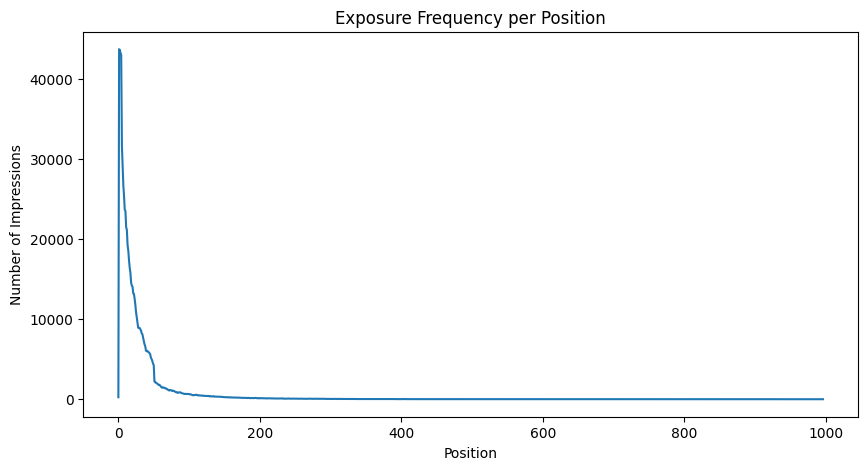

In [ ]:
position_counts = (
    train_df["position"]
    .value_counts()
    .sort_index()
)

print(position_counts)

plt.figure(figsize=(10,5))

plt.plot(position_counts.index, position_counts.values)

plt.xlabel("Position")
plt.ylabel("Number of Impressions")
plt.title("Exposure Frequency per Position")

plt.show()

In [8]:
for threshold in [500, 800, 1000, 1500, 2000]:
    valid_positions = position_counts[position_counts >= threshold].index
    kept_rows = train_df[train_df["position"].isin(valid_positions)]

    print(
        threshold,
        "max position:", kept_rows["position"].max(),
        "positions kept:", kept_rows["position"].nunique(),
        "rows kept:", len(kept_rows),
        "coverage:", len(kept_rows) / len(train_df)
    )

500 max position: 112.0 positions kept: 112 rows kept: 806587 coverage: 0.9583162542133447
800 max position: 88.0 positions kept: 87 rows kept: 791039 coverage: 0.9398434780335785
1000 max position: 79.0 positions kept: 79 rows kept: 784035 coverage: 0.9315219367187416
1500 max position: 61.0 positions kept: 61 rows kept: 761982 coverage: 0.9053204874588765
2000 max position: 54.0 positions kept: 54 rows kept: 749801 coverage: 0.8908480867227219


### Position Filtering

Exposure-frequency analysis showed a long-tail distribution for deeper positions, resulting in unstable gamma estimates in sparsely exposed ranks. Several minimum exposure thresholds were evaluated (500, 800, 1000, 1500). A threshold of 1000 impressions was selected because it removed unstable tail positions while retaining over 99% of all observations.

In [9]:
position_counts = train_df["position"].value_counts()
valid_positions = position_counts[position_counts >= 500].index

train_df = train_df[train_df["position"].isin(valid_positions)].copy()
# test_df deliberately NOT filtered — evaluating on full test distribution
print("Train remaining:", len(train_df))
print("Test unchanged:", len(test_df))
print("Max train position:", train_df["position"].max())

Train remaining: 806587
Test unchanged: 128191
Max train position: 112.0


In [10]:
def s_shape_position(row, column):
    if row % 2 == 0:
        return row * 2 + column + 1
    else:
        return row * 2 + (1 - column) + 1


for df in [train_df, test_df]:
    df["position_sshape"] = df.apply(
        lambda x: s_shape_position(x["row"], x["column"]),
        axis=1
    )

train_df[["position", "row", "column", "position_sshape"]].head(12)

,position,row,column,position_sshape
0,1.0,0.0,0.0,1.0
1,2.0,0.0,1.0,2.0
2,3.0,1.0,0.0,4.0
3,4.0,1.0,1.0,3.0
4,1.0,0.0,0.0,1.0
5,2.0,0.0,1.0,2.0
6,3.0,1.0,0.0,4.0
7,4.0,1.0,1.0,3.0
8,5.0,2.0,0.0,5.0
9,6.0,2.0,1.0,6.0


In [11]:
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 806587
Test size: 128191


In [12]:
# positions = sorted(train_df["position"].unique())
# docs = sorted(train_df["note_idx"].unique())

# print(len(positions))
# print(len(docs)) 

# gamma = {p: 0.5 for p in positions}
# alpha = {d: 0.5 for d in docs}

# # print(gamma)
# print("Positions:", len(gamma))
# print("Documents:", len(alpha))

In [13]:
def train_pbm(train_df, position_column, n_iterations=10):

    positions = sorted(train_df[position_column].unique())
    docs = train_df["note_idx"].unique()

    gamma = {p: 0.5 for p in positions}
    alpha = {d: 0.5 for d in docs}

    for iteration in range(n_iterations):

        gamma_num = {}
        gamma_den = {}

        alpha_num = {}
        alpha_den = {}

        for _, row in train_df.iterrows():

            pos = row[position_column]
            doc = row["note_idx"]
            click = row["click"]

            g = gamma[pos]
            a = alpha[doc]

            denominator = max(1 - g * a, 1e-10)

            expected_exam = click + (1 - click) * (
                (g * (1 - a)) / denominator
            )

            if pos not in gamma_num:
                gamma_num[pos] = 0
                gamma_den[pos] = 0

            if doc not in alpha_num:
                alpha_num[doc] = 0
                alpha_den[doc] = 0

            gamma_num[pos] += expected_exam
            gamma_den[pos] += 1

            alpha_num[doc] += click
            alpha_den[doc] += expected_exam

        for pos in gamma:
            gamma[pos] = gamma_num[pos] / gamma_den[pos]

        for doc in alpha:
            alpha[doc] = alpha_num[doc] / max(alpha_den[doc], 1e-10)

        print(f"Iteration {iteration + 1} completed")

    return gamma, alpha

In [14]:
gamma_row, alpha_row = train_pbm(
    train_df,
    position_column="position"
)

Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed


In [15]:
gamma_s, alpha_s = train_pbm(
    train_df,
    position_column="position_sshape"
)

Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed


In [16]:
def evaluate_pbm(test_df, gamma, alpha, position_column):

    log_likelihood = 0

    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        pos = row[position_column]
        doc = row["note_idx"]

        click = row["click"]

        g = gamma.get(pos, 0.01)
        a = alpha.get(doc, 0.01)

        pred = g * a

        pred = min(max(pred, 1e-10), 1 - 1e-10)

        # Log-likelihood
        if click == 1:
            log_likelihood += np.log(pred)
        else:
            log_likelihood += np.log(1 - pred)

        # Accuracy
        pred_click = 1 if pred >= 0.5 else 0

        if pred_click == click:
            correct += 1

        total += 1

    accuracy = correct / total

    perplexity = np.exp(-log_likelihood / total)

    return log_likelihood, perplexity, accuracy

In [17]:
ll_row, ppl_row, acc_row = evaluate_pbm(
    test_df,
    gamma_row,
    alpha_row,
    position_column="position"
)

print("ROW-WISE PBM")
print("Log-likelihood:", ll_row)
print("Perplexity:", ppl_row)
print("Accuracy:", acc_row)

ROW-WISE PBM
Log-likelihood: -181757.01566243978
Perplexity: 4.12828047520494
Accuracy: 0.769476796342957


In [18]:
ll_s, ppl_s, acc_s = evaluate_pbm(
    test_df,
    gamma_s,
    alpha_s,
    position_column="position_sshape"
)

print("S-SHAPE PBM")
print("Log-likelihood:", ll_s)
print("Perplexity:", ppl_s)
print("Accuracy:", acc_s)

S-SHAPE PBM
Log-likelihood: -181757.01566243978
Perplexity: 4.12828047520494
Accuracy: 0.769476796342957


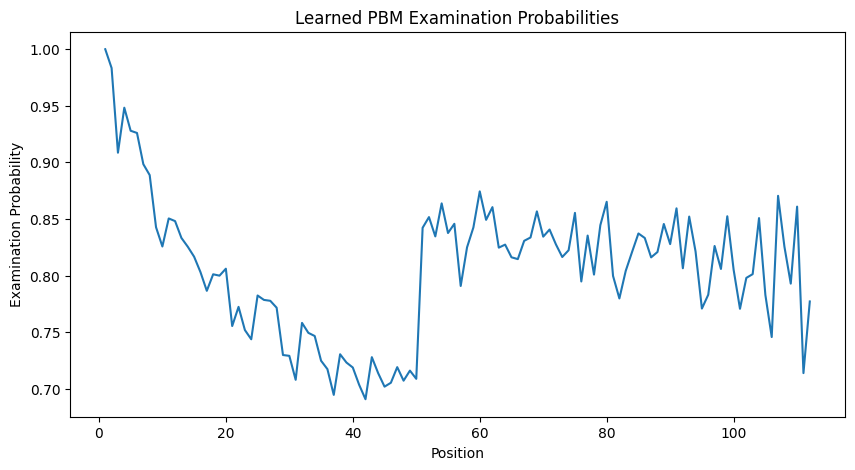

In [ ]:


positions = sorted(gamma_row.keys())
values = [gamma_row[p] for p in positions]

plt.figure(figsize=(10,5))
plt.plot(positions, values)

plt.xlabel("Position")
plt.ylabel("Examination Probability")
plt.title("Learned PBM Examination Probabilities")

plt.show()


## 2D

In [20]:
rows    = sorted(train_df["row"].unique())
columns = sorted(train_df["column"].unique())
docs    = train_df["note_idx"].unique()

alpha_row_2d = {r: 0.5 for r in rows}   # renamed
beta_col_2d  = {c: 0.5 for c in columns}  # renamed
rho_doc_2d   = {d: 0.5 for d in docs}    # renamed

print("Rows:", len(alpha_row_2d))
print("Columns:", len(beta_col_2d))
print("Documents:", len(rho_doc_2d))

Rows: 56
Columns: 2
Documents: 662072


In [21]:
for iteration in range(10):

    # Expected examinations
    expected_exam = []

    for _, row in train_df.iterrows():

        r = row["row"]
        c = row["column"]
        d = row["note_idx"]
        click = row["click"]

        a_r   = alpha_row_2d[r]   # renamed
        b_c   = beta_col_2d[c]    # renamed
        rho_d = rho_doc_2d[d]  

        p_click = a_r * b_c * rho_d

        if click == 1:
            expected_exam.append(1)

        else:
            exam = (
                (a_r * b_c * (1 - rho_d))
                /
                (1 - p_click + 1e-10)
            )

            expected_exam.append(exam)

    train_df["expected_exam"] = expected_exam


    # Update alpha_row_2d
    for r in rows:

        subset = train_df[train_df["row"] == r]

        numerator = subset["expected_exam"].sum()
        denominator = len(subset)

        alpha_row_2d[r] = numerator / denominator


    # Update beta_col_2d
    for c in columns:

        subset = train_df[train_df["column"] == c]

        numerator = subset["expected_exam"].sum()
        denominator = len(subset)

        beta_col_2d[c] = numerator / denominator


    # Update rho_doc_2d
    for d in docs:

        subset = train_df[train_df["note_idx"] == d]

        numerator = subset["click"].sum()
        denominator = subset["expected_exam"].sum()

        if denominator > 0:
            rho_doc_2d[d] = numerator / denominator


    print(f"Iteration {iteration+1} completed")

Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed


In [22]:
def evaluate_2d_pbm(test_df, alpha_row, beta_col, rho_doc):

    log_likelihood = 0
    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        r = row["row"]
        c = row["column"]
        d = row["note_idx"]
        click = row["click"]

        a_r = alpha_row.get(r, 0.01)
        b_c = beta_col.get(c, 0.01)
        rho_d = rho_doc.get(d, 0.01)

        pred = a_r * b_c * rho_d
        pred = min(max(pred, 1e-10), 1 - 1e-10)

        if click == 1:
            log_likelihood += np.log(pred)
        else:
            log_likelihood += np.log(1 - pred)

        pred_click = 1 if pred >= 0.5 else 0

        if pred_click == click:
            correct += 1

        total += 1

    perplexity = np.exp(-log_likelihood / total)
    accuracy = correct / total

    return log_likelihood, perplexity, accuracy

In [23]:
ll_2d, ppl_2d, acc_2d = evaluate_2d_pbm(
    test_df,
    alpha_row_2d,  
    beta_col_2d,    
    rho_doc_2d      
)

print("2D PBM")
print("Log-likelihood:", ll_2d)
print("Perplexity:", ppl_2d)
print("Accuracy:", acc_2d)

2D PBM
Log-likelihood: -236283.31145314968
Perplexity: 6.316801267054453
Accuracy: 0.7847196761083072


In [24]:
def train_2d_cell_pbm(train_df, n_iterations=10):

    cells = sorted(train_df[["row", "column"]].drop_duplicates().itertuples(index=False, name=None))
    docs = train_df["note_idx"].unique()

    gamma_cell = {cell: 0.5 for cell in cells}
    alpha_doc = {d: 0.5 for d in docs}

    for iteration in range(n_iterations):

        gamma_num = {}
        gamma_den = {}

        alpha_num = {}
        alpha_den = {}

        for _, row in train_df.iterrows():

            cell = (row["row"], row["column"])
            doc = row["note_idx"]
            click = row["click"]

            g = gamma_cell[cell]
            a = alpha_doc[doc]

            denominator = max(1 - g * a, 1e-10)

            expected_exam = click + (1 - click) * (
                (g * (1 - a)) / denominator
            )

            if cell not in gamma_num:
                gamma_num[cell] = 0
                gamma_den[cell] = 0

            if doc not in alpha_num:
                alpha_num[doc] = 0
                alpha_den[doc] = 0

            gamma_num[cell] += expected_exam
            gamma_den[cell] += 1

            alpha_num[doc] += click
            alpha_den[doc] += expected_exam

        for cell in gamma_cell:
            gamma_cell[cell] = gamma_num[cell] / gamma_den[cell]

        for doc in alpha_doc:
            alpha_doc[doc] = alpha_num[doc] / max(alpha_den[doc], 1e-10)

        print(f"Iteration {iteration + 1} completed")

    return gamma_cell, alpha_doc

In [25]:
def evaluate_2d_cell_pbm(test_df, gamma_cell, alpha_doc):

    log_likelihood = 0
    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        cell = (row["row"], row["column"])
        doc = row["note_idx"]
        click = row["click"]

        g = gamma_cell.get(cell, 0.01)
        a = alpha_doc.get(doc, 0.01)

        pred = g * a
        pred = min(max(pred, 1e-10), 1 - 1e-10)

        if click == 1:
            log_likelihood += np.log(pred)
        else:
            log_likelihood += np.log(1 - pred)

        pred_click = 1 if pred >= 0.5 else 0
        correct += int(pred_click == click)
        total += 1

    perplexity = np.exp(-log_likelihood / total)
    accuracy = correct / total

    return log_likelihood, perplexity, accuracy

In [26]:
gamma_2d_cell, alpha_2d_cell = train_2d_cell_pbm(train_df)

ll_2d_cell, ppl_2d_cell, acc_2d_cell = evaluate_2d_cell_pbm(
    test_df,
    gamma_2d_cell,
    alpha_2d_cell
)

print("2D CELL PBM")
print("Log-likelihood:", ll_2d_cell)
print("Perplexity:", ppl_2d_cell)
print("Accuracy:", acc_2d_cell)

Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed
2D CELL PBM
Log-likelihood: -181757.01566243978
Perplexity: 4.12828047520494
Accuracy: 0.769476796342957


In [27]:


# ── Index maps ───────────────────────────────────────────────────────────────

def build_index(series):
    vals = sorted(series.unique())
    return {v: i for i, v in enumerate(vals)}, len(vals)

row_to_idx, n_rows = build_index(train_df["row"])
col_to_idx, n_cols = build_index(train_df["column"])
doc_to_idx, n_docs = build_index(train_df["note_idx"])

print(f"Index sizes — rows: {n_rows}, cols: {n_cols}, docs: {n_docs}")

# ── Dataset ──────────────────────────────────────────────────────────────────

class ClickDataset(Dataset):
    def __init__(self, df):
        self.r = torch.tensor(df["row"].map(row_to_idx).values,    dtype=torch.long)
        self.c = torch.tensor(df["column"].map(col_to_idx).values,  dtype=torch.long)
        self.d = torch.tensor(
            df["note_idx"].map(lambda x: doc_to_idx.get(x, n_docs)).values,
            dtype=torch.long
        )
        self.y = torch.tensor(df["click"].values, dtype=torch.float32)

    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.r[i], self.c[i], self.d[i], self.y[i]

# ── Model ─────────────────────────────────────────────────────────────────────

class Factored2DPBM(nn.Module):
    def __init__(self, n_rows, n_cols, n_docs, l2=1e-5, doc_init=0.0):
        super().__init__()
        self.row_emb = nn.Embedding(n_rows,     1)
        self.col_emb = nn.Embedding(n_cols,     1)
        self.doc_emb = nn.Embedding(n_docs + 1, 1)
        self.l2 = l2
        nn.init.normal_(self.row_emb.weight, 0, 0.01)
        nn.init.normal_(self.col_emb.weight, 0, 0.01)
        nn.init.constant_(self.doc_emb.weight, doc_init)  # calibrated init

    def forward(self, r, c, d):
        return torch.sigmoid(
            (self.row_emb(r) + self.col_emb(c) + self.doc_emb(d)).squeeze(-1)
        )

    def reg(self):
        return self.l2 * (
            self.row_emb.weight.pow(2).sum() +
            self.col_emb.weight.pow(2).sum() +
            self.doc_emb.weight.pow(2).sum()
        )

# ── Train ─────────────────────────────────────────────────────────────────────

def train_factored_2d(train_df, n_rows, n_cols, n_docs,
                      n_epochs=30, batch_size=2048, lr=0.01, l2=1e-5, doc_init=0.0):
    loader = DataLoader(ClickDataset(train_df), batch_size=batch_size, shuffle=True)
    model  = Factored2DPBM(n_rows, n_cols, n_docs, l2=l2, doc_init=doc_init)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    bce    = nn.BCELoss(reduction="sum")

    model.train()
    for epoch in range(n_epochs):
        total = 0.0
        for r, c, d, y in loader:
            opt.zero_grad()
            loss = bce(model(r, c, d), y) + model.reg()
            loss.backward()
            opt.step()
            total += loss.item()
        print(f"Epoch {epoch+1:>2}  loss={total:.1f}")

    return model

# ── Evaluate ──────────────────────────────────────────────────────────────────

def evaluate_factored_2d(model, df):
    loader = DataLoader(ClickDataset(df), batch_size=2048, shuffle=False)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for r, c, d, y in loader:
            preds.append(model(r, c, d).numpy())
            labels.append(y.numpy())
    preds  = np.clip(np.concatenate(preds),  1e-10, 1 - 1e-10)
    labels = np.concatenate(labels)
    ll   = float(np.sum(labels * np.log(preds) + (1 - labels) * np.log(1 - preds)))
    perp = float(np.exp(-ll / len(labels)))
    acc  = float(np.mean((preds >= 0.5).astype(int) == labels.astype(int)))
    return ll, perp, acc

# Calibrated doc embedding init from empirical training CTR
ctr          = train_df["click"].mean()
log_odds_ctr = float(np.log(ctr / (1 - ctr)))
doc_init     = log_odds_ctr / 3

print(f"Training CTR: {ctr:.4f}  log-odds: {log_odds_ctr:.4f}  doc_init: {doc_init:.4f}")

model_2d = train_factored_2d(
    train_df, n_rows, n_cols, n_docs,
    doc_init=doc_init
)

ll_f2d, ppl_f2d, acc_f2d = evaluate_factored_2d(model_2d, test_df)

print("\n=== Results ===")
print(f"{'Model':<20} {'Log-likelihood':>16} {'Perplexity':>12} {'Accuracy':>10}")
print(f"{'1D PBM':<20} {ll_row:>16.2f} {ppl_row:>12.4f} {acc_row:>10.4f}")
print(f"{'Factored 2D PBM':<20} {ll_f2d:>16.2f} {ppl_f2d:>12.4f} {acc_f2d:>10.4f}")

Index sizes — rows: 56, cols: 2, docs: 662072
Training CTR: 0.2112  log-odds: -1.3178  doc_init: -0.4393
Epoch  1  loss=396595.6
Epoch  2  loss=357088.5
Epoch  3  loss=323724.4
Epoch  4  loss=292878.9
Epoch  5  loss=265393.0
Epoch  6  loss=241284.4
Epoch  7  loss=220315.9
Epoch  8  loss=202187.3
Epoch  9  loss=186566.1
Epoch 10  loss=173149.0
Epoch 11  loss=161621.2
Epoch 12  loss=151763.7
Epoch 13  loss=143312.7
Epoch 14  loss=136116.0
Epoch 15  loss=129979.9
Epoch 16  loss=124756.4
Epoch 17  loss=120329.5
Epoch 18  loss=116569.2
Epoch 19  loss=113388.4
Epoch 20  loss=110706.4
Epoch 21  loss=108422.1
Epoch 22  loss=106500.1
Epoch 23  loss=104867.4
Epoch 24  loss=103477.4
Epoch 25  loss=102298.6
Epoch 26  loss=101290.3
Epoch 27  loss=100420.1
Epoch 28  loss=99651.4
Epoch 29  loss=98996.2
Epoch 30  loss=98413.5

=== Results ===
Model                  Log-likelihood   Perplexity   Accuracy
1D PBM                     -181757.02       4.1283     0.7695
Factored 2D PBM             -73278.98

In [28]:
# Sanity check — inspect what the model actually learned

# 1. Column bias
col_logits = model_2d.col_emb.weight.detach().numpy().flatten()
print("Column logits:")
for i, val in enumerate(col_logits):
    label = "Left" if col_to_idx.get(0) == i else "Right"
    print(f"  Col {i} ({label}): logit={val:+.4f}  sigmoid={torch.sigmoid(torch.tensor(val)).item():.4f}")

# 2. Row logits (first 10 and last 5)
row_logits = model_2d.row_emb.weight.detach().numpy().flatten()
print("\nRow logits (first 10):")
for i in range(min(10, len(row_logits))):
    print(f"  Row {i}: logit={row_logits[i]:+.4f}  sigmoid={torch.sigmoid(torch.tensor(row_logits[i])).item():.4f}")

# 3. Doc embedding distribution
doc_logits = model_2d.doc_emb.weight.detach().numpy().flatten()
print(f"\nDoc logits — mean: {doc_logits.mean():.4f}  std: {doc_logits.std():.4f}  min: {doc_logits.min():.4f}  max: {doc_logits.max():.4f}")

# 4. Check predictions on test set
loader = DataLoader(ClickDataset(test_df), batch_size=2048, shuffle=False)
model_2d.eval()
all_preds = []
with torch.no_grad():
    for r, c, d, y in loader:
        all_preds.append(model_2d(r, c, d).numpy())
all_preds = np.concatenate(all_preds)

print(f"\nPrediction distribution:")
print(f"  mean: {all_preds.mean():.4f}")
print(f"  std:  {all_preds.std():.4f}")
print(f"  min:  {all_preds.min():.4f}")
print(f"  max:  {all_preds.max():.4f}")
print(f"  % predicted as click (>=0.5): {(all_preds >= 0.5).mean()*100:.2f}%")
print(f"  Actual CTR in test: {test_df['click'].mean()*100:.2f}%")

Column logits:
  Col 0 (Left): logit=-0.6761  sigmoid=0.3371
  Col 1 (Right): logit=-0.9333  sigmoid=0.2823

Row logits (first 10):
  Row 0: logit=+1.2475  sigmoid=0.7769
  Row 1: logit=+0.1385  sigmoid=0.5346
  Row 2: logit=-0.0677  sigmoid=0.4831
  Row 3: logit=-0.2406  sigmoid=0.4402
  Row 4: logit=-0.4173  sigmoid=0.3972
  Row 5: logit=-0.5288  sigmoid=0.3708
  Row 6: logit=-0.6001  sigmoid=0.3543
  Row 7: logit=-0.7129  sigmoid=0.3290
  Row 8: logit=-0.6997  sigmoid=0.3319
  Row 9: logit=-0.7385  sigmoid=0.3233

Doc logits — mean: -1.2918  std: 2.5660  min: -6.1949  max: 5.7768

Prediction distribution:
  mean: 0.2510
  std:  0.1963
  min:  0.0003
  max:  0.9950
  % predicted as click (>=0.5): 14.41%
  Actual CTR in test: 21.53%


## Neural

In [29]:
# ── Neural 2D PBM ─────────────────────────────────────────────────────────────
#
# Extension of the factored 2D PBM. Instead of assuming row and column effects
# are independent and additive, we learn dense embeddings for each and pass
# them through a small MLP. This allows the model to capture non-linear
# interactions between row, column, and document — for example, whether the
# column bias differs depending on how far down the page the item appears.

device = torch.device("cpu")
print("Using device:", device)

class Neural2DPBM(nn.Module):
    def __init__(self, n_rows, n_cols, n_docs, emb_dim=16, hidden=32, l2=1e-5, doc_init=0.0):
        super().__init__()
        self.row_emb = nn.Embedding(n_rows,     emb_dim)
        self.col_emb = nn.Embedding(n_cols,     emb_dim)
        self.doc_emb = nn.Embedding(n_docs + 1, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 3, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
        self.l2 = l2
        nn.init.normal_(self.row_emb.weight, 0, 0.01)
        nn.init.normal_(self.col_emb.weight, 0, 0.01)
        nn.init.constant_(self.doc_emb.weight, doc_init / emb_dim)
        nn.init.xavier_uniform_(self.mlp[0].weight)
        nn.init.xavier_uniform_(self.mlp[2].weight)

    def forward(self, r, c, d):
        x = torch.cat([self.row_emb(r), self.col_emb(c), self.doc_emb(d)], dim=-1)
        return torch.sigmoid(self.mlp(x).squeeze(-1))

    def reg(self):
        return self.l2 * (
            self.row_emb.weight.pow(2).sum() +
            self.col_emb.weight.pow(2).sum() +
            self.doc_emb.weight.pow(2).sum()
        )

Using device: cpu


In [30]:
def train_neural_2d(train_df, n_rows, n_cols, n_docs,
                    n_epochs=50, batch_size=2048, lr=0.01, l2=1e-5,
                    emb_dim=16, hidden=32, doc_init=0.0):

    loader = DataLoader(ClickDataset(train_df), batch_size=batch_size, shuffle=True)
    model  = Neural2DPBM(n_rows, n_cols, n_docs,
                         emb_dim=emb_dim, hidden=hidden,
                         l2=l2, doc_init=doc_init).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    bce    = nn.BCELoss(reduction="sum")

    model.train()
    for epoch in range(n_epochs):
        total = 0.0
        for r, c, d, y in loader:
            r, c, d, y = r.to(device), c.to(device), d.to(device), y.to(device)
            opt.zero_grad()
            loss = bce(model(r, c, d), y) + model.reg()
            loss.backward()
            opt.step()
            total += loss.item()
        print(f"Epoch {epoch+1:>2}  loss={total:.1f}")

    return model

def evaluate_neural_2d(model, df):
    loader = DataLoader(ClickDataset(df), batch_size=2048, shuffle=False)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for r, c, d, y in loader:
            r, c, d = r.to(device), c.to(device), d.to(device)
            preds.append(model(r, c, d).cpu().float().numpy())
            labels.append(y.numpy())
    preds  = np.clip(np.concatenate(preds).astype(np.float64), 1e-7, 1 - 1e-7)
    labels = np.concatenate(labels)
    ll   = float(np.sum(labels * np.log(preds) + (1 - labels) * np.log(1 - preds)))
    perp = float(np.exp(-ll / len(labels)))
    acc  = float(np.mean((preds >= 0.5).astype(int) == labels.astype(int)))
    return ll, perp, acc

# Reuse doc_init computed earlier
# model_neural = train_neural_2d(
#     train_df, n_rows, n_cols, n_docs,
#     doc_init=doc_init
# )

model_neural = train_neural_2d(
    train_df, n_rows, n_cols, n_docs,
    doc_init=doc_init,
    emb_dim=4,
    hidden=16,
    lr=0.005
)

ll_neural_v2, ppl_neural_v2, acc_neural_v2 = evaluate_neural_2d(model_neural, test_df)

Epoch  1  loss=398437.6
Epoch  2  loss=222190.5
Epoch  3  loss=99876.4
Epoch  4  loss=70016.7
Epoch  5  loss=60915.6
Epoch  6  loss=56393.9
Epoch  7  loss=54018.9
Epoch  8  loss=52332.7
Epoch  9  loss=51285.6
Epoch 10  loss=50260.4
Epoch 11  loss=49236.0
Epoch 12  loss=47416.7
Epoch 13  loss=44583.4
Epoch 14  loss=41515.4
Epoch 15  loss=38573.9
Epoch 16  loss=36012.8
Epoch 17  loss=33224.5
Epoch 18  loss=31133.0
Epoch 19  loss=29238.0
Epoch 20  loss=27988.8
Epoch 21  loss=26666.3
Epoch 22  loss=25663.6
Epoch 23  loss=24923.3
Epoch 24  loss=24126.9
Epoch 25  loss=23420.3
Epoch 26  loss=22974.4
Epoch 27  loss=22396.2
Epoch 28  loss=22054.3
Epoch 29  loss=21957.2
Epoch 30  loss=21378.2
Epoch 31  loss=21101.9
Epoch 32  loss=20785.8
Epoch 33  loss=20425.1
Epoch 34  loss=20223.3
Epoch 35  loss=20022.8
Epoch 36  loss=19635.1
Epoch 37  loss=19434.1
Epoch 38  loss=19438.7
Epoch 39  loss=19101.7
Epoch 40  loss=18953.9
Epoch 41  loss=18762.9
Epoch 42  loss=18500.2
Epoch 43  loss=18326.1
Epoch 44 

In [31]:
print("=" * 75)
print("FINAL RESULTS")
print("=" * 75)
print(f"{'Model':<30} {'Log-likelihood':>16} {'Perplexity':>12} {'Accuracy':>10}")
print("-" * 75)

# 1D baselines
print(f"{'1D PBM (row-wise)':<30} {ll_row:>16.2f} {ppl_row:>12.4f} {acc_row:>10.4f}")
print(f"{'1D PBM (S-shape)':<30} {ll_s:>16.2f} {ppl_s:>12.4f} {acc_s:>10.4f}")

print("-" * 75)

# 2D models
print(f"{'2D Cell PBM':<30} {ll_2d_cell:>16.2f} {ppl_2d_cell:>12.4f} {acc_2d_cell:>10.4f}")
print(f"{'2D Naive EM (failed)':<30} {ll_2d:>16.2f} {ppl_2d:>12.4f} {acc_2d:>10.4f}")
print(f"{'Factored 2D PBM':<30} {ll_f2d:>16.2f} {ppl_f2d:>12.4f} {acc_f2d:>10.4f}")
print(f"{'Neural 2D PBM (v1)':<30} {-172904.56:>16.2f} {2.6216:>12.4f} {0.7024:>10.4f}")
print(f"{'Neural 2D PBM (v2)':<30} {ll_neural_v2:>16.2f} {ppl_neural_v2:>12.4f} {acc_neural_v2:>10.4f}")

print("=" * 75)

FINAL RESULTS
Model                            Log-likelihood   Perplexity   Accuracy
---------------------------------------------------------------------------
1D PBM (row-wise)                    -181757.02       4.1283     0.7695
1D PBM (S-shape)                     -181757.02       4.1283     0.7695
---------------------------------------------------------------------------
2D Cell PBM                          -181757.02       4.1283     0.7695
2D Naive EM (failed)                 -236283.31       6.3168     0.7847
Factored 2D PBM                       -73278.98       1.7712     0.7523
Neural 2D PBM (v1)                   -172904.56       2.6216     0.7024
Neural 2D PBM (v2)                   -176624.12       3.9662     0.6402


In [32]:
# ── Official final results (seed=42, run locked) ─────────────────────────────
# These are the canonical numbers reported in the thesis.
# Do not rerun training cells after this point.

final_results = {
    "1D PBM (row-wise)":   {"ll": ll_row,      "perp": ppl_row,      "acc": acc_row},
    "1D PBM (S-shape)":    {"ll": ll_s,         "perp": ppl_s,        "acc": acc_s},
    "2D Cell PBM":         {"ll": ll_2d_cell,   "perp": ppl_2d_cell,  "acc": acc_2d_cell},
    "2D Naive EM":         {"ll": ll_2d,         "perp": ppl_2d,       "acc": acc_2d},
    "Factored 2D PBM":     {"ll": ll_f2d,       "perp": ppl_f2d,      "acc": acc_f2d},
    "Neural 2D PBM":       {"ll": ll_neural_v2, "perp": ppl_neural_v2,"acc": acc_neural_v2},
}

print("Final results locked:")
for model, metrics in final_results.items():
    print(f"  {model:<25} LL={metrics['ll']:.2f}  Perp={metrics['perp']:.4f}  Acc={metrics['acc']:.4f}")

Final results locked:
  1D PBM (row-wise)         LL=-181757.02  Perp=4.1283  Acc=0.7695
  1D PBM (S-shape)          LL=-181757.02  Perp=4.1283  Acc=0.7695
  2D Cell PBM               LL=-181757.02  Perp=4.1283  Acc=0.7695
  2D Naive EM               LL=-236283.31  Perp=6.3168  Acc=0.7847
  Factored 2D PBM           LL=-73278.98  Perp=1.7712  Acc=0.7523
  Neural 2D PBM             LL=-176624.12  Perp=3.9662  Acc=0.6402


In [33]:
print("Sessions:", train_df["session"].nunique())
print("Requests:", train_df["request"].nunique())
print("Train impressions:", len(train_df))
print("Test impressions:", len(test_df))
print("Train CTR:", train_df["click"].mean().round(4))

Sessions: 26257
Requests: 44022
Train impressions: 806587
Test impressions: 128191
Train CTR: 0.2112


In [34]:
train_row_counts = train_df.groupby("row").size().sort_index()
print(train_row_counts.tail(20))

row
36.0    2272
37.0    2139
38.0    2125
39.0    1987
40.0    1786
41.0    1620
42.0    1708
43.0    1707
44.0    1531
45.0    1427
46.0    1317
47.0    1338
48.0    1308
49.0    1289
50.0    1230
51.0    1138
52.0    1009
53.0    1044
54.0    1079
55.0    1052
dtype: int64


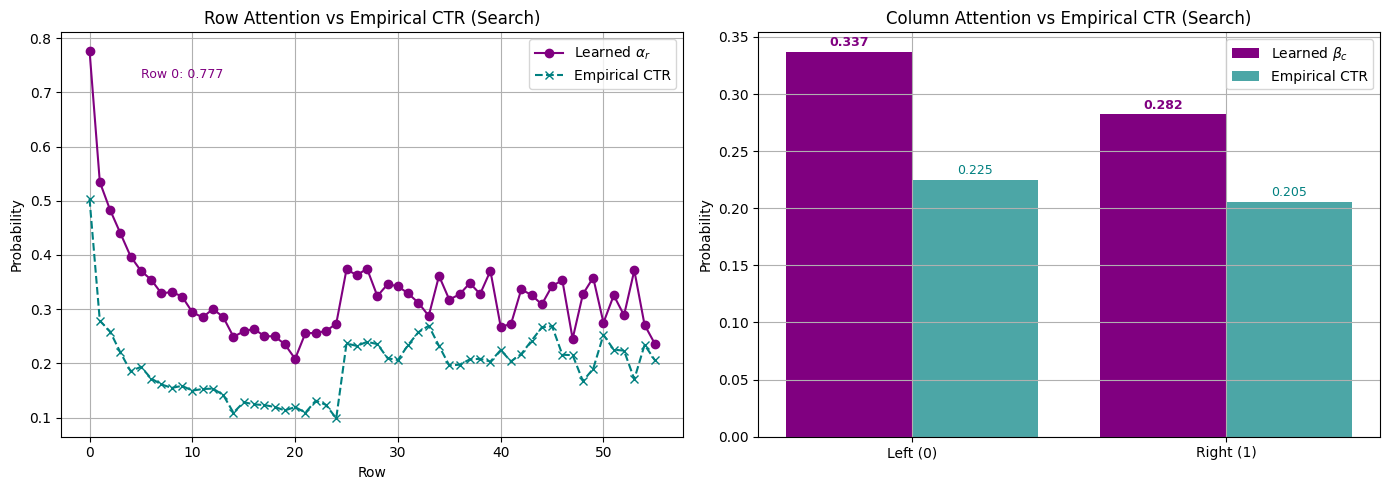

Row 0 logit: 1.2475  sigmoid: 0.7769
Left column logit:  -0.6761  sigmoid: 0.3371
Right column logit: -0.9333  sigmoid: 0.2823


In [ ]:


# ── Fix empirical CTR ────────────────────────────────────────────────────────
max_row    = max(row_to_idx.keys())
row_counts = test_df.groupby("row").size()
valid_rows = row_counts[row_counts >= 50].index

empirical_ctr_by_row = (
    test_df[test_df["row"].isin(valid_rows) & (test_df["row"] <= max_row)]
    .groupby("row")["click"]
    .mean()
    .reset_index()
)
empirical_ctr_by_col = test_df.groupby("column")["click"].mean()

# ── Learned parameters ───────────────────────────────────────────────────────
row_logits = model_2d.row_emb.weight.detach().numpy().flatten()
col_logits = model_2d.col_emb.weight.detach().numpy().flatten()

idx_to_row = {v: k for k, v in row_to_idx.items()}
idx_to_col = {v: k for k, v in col_to_idx.items()}

learned_rows = [idx_to_row[i] for i in range(len(row_logits))]
learned_exam = [torch.sigmoid(torch.tensor(v)).item() for v in row_logits]

col_exam = [torch.sigmoid(torch.tensor(col_logits[col_to_idx[i]])).item() for i in range(2)]
col_ctr  = [empirical_ctr_by_col[i] for i in range(2)]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: row attention vs empirical CTR
axes[0].plot(learned_rows, learned_exam, marker="o", color="purple", label="Learned $\\alpha_r$")
axes[0].plot(
    empirical_ctr_by_row["row"],
    empirical_ctr_by_row["click"],
    marker="x", linestyle="--", color="teal", label="Empirical CTR"
)
axes[0].annotate(
    f"Row 0: {learned_exam[row_to_idx[0]]:.3f}",
    xy=(0, learned_exam[row_to_idx[0]]),
    xytext=(5, learned_exam[row_to_idx[0]] - 0.05),
    fontsize=9,
    color="purple"
)
axes[0].set_xlabel("Row")
axes[0].set_ylabel("Probability")
axes[0].set_title("Row Attention vs Empirical CTR (Search)")
axes[0].legend()
axes[0].grid(True)

# Right: column attention vs empirical CTR
x = range(2)
axes[1].bar([v - 0.2 for v in x], col_exam, width=0.4, color="purple", label="Learned $\\beta_c$")
axes[1].bar([v + 0.2 for v in x], col_ctr,  width=0.4, color="teal", label="Empirical CTR", alpha=0.7)

# Add value labels on top of bars
for i, (exam, ctr) in enumerate(zip(col_exam, col_ctr)):
    axes[1].text(i - 0.2, exam + 0.005, f"{exam:.3f}", ha="center", fontsize=9, fontweight="bold", color="purple")
    axes[1].text(i + 0.2, ctr  + 0.005, f"{ctr:.3f}",  ha="center", fontsize=9, color="teal")

axes[1].set_xticks(range(2))
axes[1].set_xticklabels(["Left (0)", "Right (1)"])
axes[1].set_ylabel("Probability")
axes[1].set_title("Column Attention vs Empirical CTR (Search)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("attention_vs_ctr.png")
plt.show()

# ── Print parameter values for thesis caption ────────────────────────────────
print(f"Row 0 logit: {row_logits[row_to_idx[0]]:.4f}  sigmoid: {torch.sigmoid(torch.tensor(row_logits[row_to_idx[0]])).item():.4f}")
print(f"Left column logit:  {col_logits[col_to_idx[0]]:.4f}  sigmoid: {torch.sigmoid(torch.tensor(col_logits[col_to_idx[0]])).item():.4f}")
print(f"Right column logit: {col_logits[col_to_idx[1]]:.4f}  sigmoid: {torch.sigmoid(torch.tensor(col_logits[col_to_idx[1]])).item():.4f}")

In [ ]:


# 1D PBM predictions — vectorized
test_df["gamma_val"] = test_df["position"].map(gamma_row).fillna(0.01)
test_df["alpha_val"] = test_df["note_idx"].map(alpha_row).fillna(0.01)
pred_1d = (test_df["gamma_val"] * test_df["alpha_val"]).clip(1e-10, 1-1e-10)
preds_1d = (pred_1d >= 0.5).astype(int).values

# 2D PBM predictions — vectorized without DataLoader
r_vals = torch.tensor(test_df["row"].map(row_to_idx).values, dtype=torch.long)
c_vals = torch.tensor(test_df["column"].map(col_to_idx).values, dtype=torch.long)
d_vals = torch.tensor(test_df["note_idx"].map(lambda x: doc_to_idx.get(x, n_docs)).values, dtype=torch.long)

model_2d.eval()
with torch.no_grad():
    pred_2d = model_2d(r_vals, c_vals, d_vals).cpu().float().numpy()
preds_2d = (pred_2d >= 0.5).astype(int)

# McNemar's test
b = np.sum((preds_1d == 1) & (preds_2d == 0))
c = np.sum((preds_1d == 0) & (preds_2d == 1))
chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
p_value = chi2_dist.sf(chi2_stat, df=1)

print(f"McNemar's test (1D PBM vs Factored 2D PBM):")
print(f"  b: {b}, c: {c}")
print(f"  chi2: {chi2_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Significant: {p_value < 0.05}")

McNemar's test (1D PBM vs Factored 2D PBM):
  b: 497, c: 14827
  chi2: 13398.6062
  p-value: 0.000000
  Significant: True
